<a href="https://colab.research.google.com/github/leonidasf300/OUU2026/blob/main/robust_coordination.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Robust Relay Coordination Model
Este notebook está preparado para ejecutarse en Google Colab. Sigue el orden de las celdas para instalar el solver, cargar tus datos y optimizar el sistema.

In [ ]:
import matplotlib.pyplot as plt

### 1. Instalación de Dependencias
Se instalará Pyomo y la librería `highspy` que contiene el motor matemático de HiGHS, altamente compatible con Colab.

In [ ]:
!pip install -q pyomo pandas numpy matplotlib highspy
print("✅ Dependencias instaladas correctamente.")

✅ Dependencias instaladas correctamente.


### 2. Carga de Datos
Ejecuta esta celda y usa el botón **'Elegir archivos'** para subir tu archivo `beta_df.csv`.

In [ ]:
import os
from google.colab import files

if not os.path.exists('beta_df.csv'):
    print("Por favor, sube tu archivo 'beta_df.csv':")
    uploaded = files.upload()
    if 'beta_df.csv' in uploaded:
        print("✅ Archivo cargado exitosamente.")
else:
    print("✅ El archivo 'beta_df.csv' ya se encuentra en el entorno.")

✅ El archivo 'beta_df.csv' ya se encuentra en el entorno.


### 3. Modelo Robusto
El script procesará las curvas, construirá las restricciones robustas y resolverá el problema usando `appsi_highs`.

In [ ]:
import pandas as pd
import numpy as np
import pyomo.environ as pyo

# =====================================================================
# 1. DATA LOADING AND PROCESSING
# =====================================================================
print("--- Starting data processing ---")
csv_path = 'beta_df.csv'
try:
    beta_df = pd.read_csv(csv_path)
except FileNotFoundError:
    print(f"File {csv_path} not found. Ensure it was uploaded correctly.")
    raise

# Filter out negative Beta values
filtered_df = beta_df[beta_df['Beta'] >= 0]

# System Sets Definition
R = ['R1', 'R2', 'R3']
C = ['STI', 'SI'] # Add 'VI', 'EI' if they exist in your actual CSV dataset
P = [('R2', 'R1'), ('R3', 'R1'), ('R3', 'R2')] # (Principal relay i, Backup relay j)
F = 'F1' # Target fault for coordination

# Dictionaries to store extracted parameters
k1_dict = {}
k2_dict = {}
beta0_dict = {}  # Nominal (mean) value of beta_jq
betaL_dict = {}  # Uncertainty limit (e.g., maximum absolute deviation)
beta_obj_dict = {} # Mean betas for the objective function

# EXTRACTION OF k1, k2 AND NOMINAL PARAMETERS
for i, j in P:
    for c in C:
        for q in C:
            df_prin = filtered_df[(filtered_df['Rele'] == i) & (filtered_df['Curva'] == c) & (filtered_df['Falla'] == F)]
            df_back = filtered_df[(filtered_df['Rele'] == j) & (filtered_df['Curva'] == q) & (filtered_df['Falla'] == F)]

            df_merged = pd.merge(df_prin, df_back, on='Distancia', suffixes=('_prin', '_back')).sort_values(by='Distancia')

            y = df_merged['Beta_prin'].to_numpy()
            x = df_merged['Beta_back'].to_numpy()

            if len(x) >= 2:
                k2, k1 = np.polyfit(x, y, 1)
            else:
                k2, k1 = 1.0, 0.0

            k1_dict[(i, j, q, c)] = k1
            k2_dict[(i, j, q, c)] = k2

            if (j, q) not in beta0_dict:
                if len(x) > 0:
                    b0 = np.mean(x)
                    bl = np.max(np.abs(x - b0))
                    if bl == 0:
                        bl = b0 * 0.01
                else:
                    b0 = 1.0
                    bl = 0.1

                beta0_dict[(j, q)] = b0
                betaL_dict[(j, q)] = bl

for i in R:
    for c in C:
        df_obj = filtered_df[(filtered_df['Rele'] == i) & (filtered_df['Curva'] == c)]
        beta_obj_dict[(i, c)] = df_obj['Beta'].mean() if not df_obj.empty else 1.0

# =====================================================================
# 2. PYOMO ROBUST MODEL CONSTRUCTION
# =====================================================================
print("--- Building Robust Model in Pyomo ---")

model = pyo.ConcreteModel(name="Robust_Coordination_V2")

model.R = pyo.Set(initialize=R)
model.C = pyo.Set(initialize=C)
model.P = pyo.Set(dimen=2, initialize=P)

model.CTI = pyo.Param(initialize=0.2)
model.M   = pyo.Param(initialize=1000.0)
model.y_lb = pyo.Param(initialize=0.0005)
model.y_ub = pyo.Param(initialize=1.2)

C_index = {"STI": 0.0, "SI": 0.0, "VI": 0.0, "EI": 0.0}
def c_param_init(model, c):
    return C_index.get(c, 0.0)
model.C_param = pyo.Param(model.C, initialize=c_param_init)

model.k1    = pyo.Param(model.P, model.C, model.C, initialize=k1_dict)
model.k2    = pyo.Param(model.P, model.C, model.C, initialize=k2_dict)
model.beta0 = pyo.Param(model.R, model.C, initialize=beta0_dict, default=1.0)
model.betaL = pyo.Param(model.R, model.C, initialize=betaL_dict, default=0.1)
model.beta_obj = pyo.Param(model.R, model.C, initialize=beta_obj_dict)

model.y = pyo.Var(model.R, model.C, domain=pyo.NonNegativeReals)
model.x = pyo.Var(model.R, model.C, domain=pyo.Binary)
model.z = pyo.Var(model.P, model.C, model.C, domain=pyo.NonNegativeReals)

def obj_rule(model):
    return sum(model.beta_obj[i, c] * model.y[i, c] + model.x[i, c] * model.C_param[c]
               for i in model.R for c in model.C)
model.objective = pyo.Objective(rule=obj_rule, sense=pyo.minimize)

def single_curve_rule(model, i):
    return sum(model.x[i, c] for c in model.C) == 1
model.single_curve = pyo.Constraint(model.R, rule=single_curve_rule)

def tms_lower_rule(model, i, c):
    return model.y[i, c] >= model.y_lb * model.x[i, c]
model.tms_lower = pyo.Constraint(model.R, model.C, rule=tms_lower_rule)

def tms_upper_rule(model, i, c):
    return model.y[i, c] <= model.y_ub * model.x[i, c]
model.tms_upper = pyo.Constraint(model.R, model.C, rule=tms_upper_rule)

def rc_base_rule(model, i, j, q, c):
    nominal_part = (model.k1[i,j,q,c] * model.y[i,c] +
                    model.k2[i,j,q,c] * model.beta0[j,q] * model.y[i,c] -
                    model.beta0[j,q] * model.y[j,q] +
                    model.C_param[c] - model.C_param[q] + model.CTI)
    return nominal_part + model.z[i,j,q,c] <= model.M * (2 - model.x[j,q] - model.x[i,c])
model.rc_base = pyo.Constraint(model.P, model.C, model.C, rule=rc_base_rule)

def rc_z_pos_rule(model, i, j, q, c):
    uncertainty = model.k2[i,j,q,c] * model.betaL[j,q] * model.y[i,c] - model.betaL[j,q] * model.y[j,q]
    return model.z[i,j,q,c] >= uncertainty - model.M * (2 - model.x[j,q] - model.x[i,c])
model.rc_z_pos = pyo.Constraint(model.P, model.C, model.C, rule=rc_z_pos_rule)

def rc_z_neg_rule(model, i, j, q, c):
    uncertainty = model.k2[i,j,q,c] * model.betaL[j,q] * model.y[i,c] - model.betaL[j,q] * model.y[j,q]
    return model.z[i,j,q,c] >= -uncertainty - model.M * (2 - model.x[j,q] - model.x[i,c])
model.rc_z_neg = pyo.Constraint(model.P, model.C, model.C, rule=rc_z_neg_rule)

# =====================================================================
# 3. MODEL RESOLUTION
# =====================================================================
print("--- Starting Optimization ---")
try:
    # Using appsi_highs directly, fully compatible with Colab Linux environment
    solver = pyo.SolverFactory('appsi_highs')

    results = solver.solve(model, tee=True)

    print("\nOptimization Status:", results.solver.status)
    print("Termination Condition:", results.solver.termination_condition)

    print("\n--- Optimal Results ---")
    for i in model.R:
        for c in model.C:
            if pyo.value(model.x[i, c]) > 0.5:
                print(f"Relay {i} -> Selected Curve: {c} | TMS (y) = {pyo.value(model.y[i, c]):.4f}")

except Exception as e:
    print(f"\nCould not solve the model. Error details: {e}")


--- Starting data processing ---
--- Building Robust Model in Pyomo ---
--- Starting Optimization ---
Running HiGHS 1.14.0 (git hash: 7df0786): Copyright (c) 2026 under MIT licence terms
MIP has 51 rows; 24 cols; 210 nonzeros; 6 integer variables (6 binary)
Coefficient ranges:
  Matrix  [5e-04, 1e+03]
  Cost    [7e-01, 5e+00]
  Bound   [1e+00, 1e+00]
  RHS     [1e+00, 2e+03]
Presolving model
48 rows, 21 cols, 204 nonzeros 0s
48 rows, 21 cols, 204 nonzeros 0s
Presolve reductions: rows 48(-3); columns 21(-3); nonzeros 204(-6) 

Solving MIP model with:
   48 rows
   21 cols (3 binary, 0 integer, 0 implied int., 18 continuous, 0 domain fixed)
   204 nonzeros

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution; Y => HiGHS solution;
     Z => ZI Round; l => Trivial lower; p => Trivial poin

--- Generando Gráfica de Coordinación para el Modelo Robusto ---


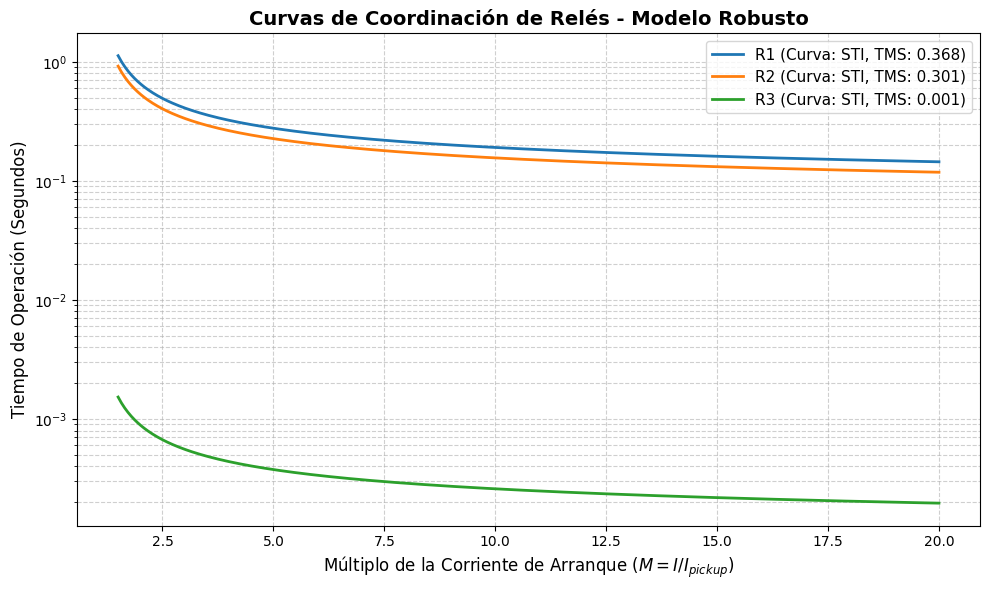

In [5]:
import matplotlib.pyplot as plt
import numpy as np

print("--- Generando Gráfica de Coordinación para el Modelo Robusto ---")

# Optimal results from the robust model execution (UhH-0C_2vQnc)
# These values are extracted from the standard output of the previous cell
robust_resultados_optimos = {
    'R1': {'curva': 'STI', 'tms': 0.3685},
    'R2': {'curva': 'STI', 'tms': 0.3012},
    'R3': {'curva': 'STI', 'tms': 0.0005}
}

# Parámetros estándar de las curvas IEC para la ecuación: t = TMS * (A / (M^B - 1)) + C
parametros_curvas = {
    "STI": {"A": 0.05, "B": 0.04, "C": 0.0},
    "SI": {"A": 0.14, "B": 0.02, "C": 0.0},
    "VI": {"A": 13.5, "B": 1.0, "C": 0.0},
    "EI": {"A": 80.0, "B": 2.0, "C": 0.0}
}

# Rango de múltiplo de corriente de arranque (M = I / I_pickup), típicamente de 1.5 a 20
M = np.linspace(1.5, 20, 500)

plt.figure(figsize=(10, 6))
colores = {'R1': '#1f77b4', 'R2': '#ff7f0e', 'R3': '#2ca02c'}

for rele, datos in robust_resultados_optimos.items():
    c_nombre = datos['curva']
    tms = datos['tms']

    A = parametros_curvas[c_nombre]['A']
    B = parametros_curvas[c_nombre]['B']
    C_cte = parametros_curvas[c_nombre]['C']

    # Ecuación estándar de tiempo de operación
    # Handle division by zero for M^B - 1.0 when M is very close to 1
    # For plotting, a small epsilon can be added or values < 1 handled
    tiempo_operacion = tms * (A / (np.power(M, B) - 1.0)) + C_cte

    plt.plot(M, tiempo_operacion, label=f'{rele} (Curva: {c_nombre}, TMS: {tms:.3f})',
             color=colores.get(rele, 'black'), linewidth=2)

# Añadir línea vertical para la corriente de cortocircuito
#M_sc = 1.090
#plt.axvline(x=M_sc, color='red', linestyle='--', label=f'Corriente de Cortocircuito (M_sc = {M_sc})')

plt.xlabel('Múltiplo de la Corriente de Arranque ($M = I / I_{pickup}$)', fontsize=12)
plt.ylabel('Tiempo de Operación (Segundos)', fontsize=12)
plt.title('Curvas de Coordinación de Relés - Modelo Robusto', fontsize=14, fontweight='bold')

plt.yscale('log') # Usualmente estas gráficas se ven mejor en escala logarítmica (Tiempo)
plt.grid(True, which="both", ls="--", alpha=0.6)
plt.legend(fontsize=11)

# Muestra la gráfica
plt.tight_layout()
plt.show()

## Modelo nominal

--- Iniciando procesamiento de datos ---
--- Construyendo Modelo Determinístico en Pyomo ---
--- Iniciando Optimización ---
Running HiGHS 1.14.0 (git hash: 7df0786): Copyright (c) 2026 under MIT licence terms
MIP has 27 rows; 12 cols; 78 nonzeros; 6 integer variables (6 binary)
Coefficient ranges:
  Matrix  [5e-04, 1e+03]
  Cost    [7e-01, 5e+00]
  Bound   [1e+00, 1e+00]
  RHS     [1e+00, 2e+03]
Presolving model
24 rows, 9 cols, 72 nonzeros 0s
20 rows, 7 cols, 56 nonzeros 0s
20 rows, 7 cols, 56 nonzeros 0s
Presolve reductions: rows 20(-7); columns 7(-5); nonzeros 56(-22) 

Solving MIP model with:
   20 rows
   7 cols (3 binary, 0 integer, 0 implied int., 4 continuous, 0 domain fixed)
   56 nonzeros

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution; Y => HiGHS solution;
     Z => ZI

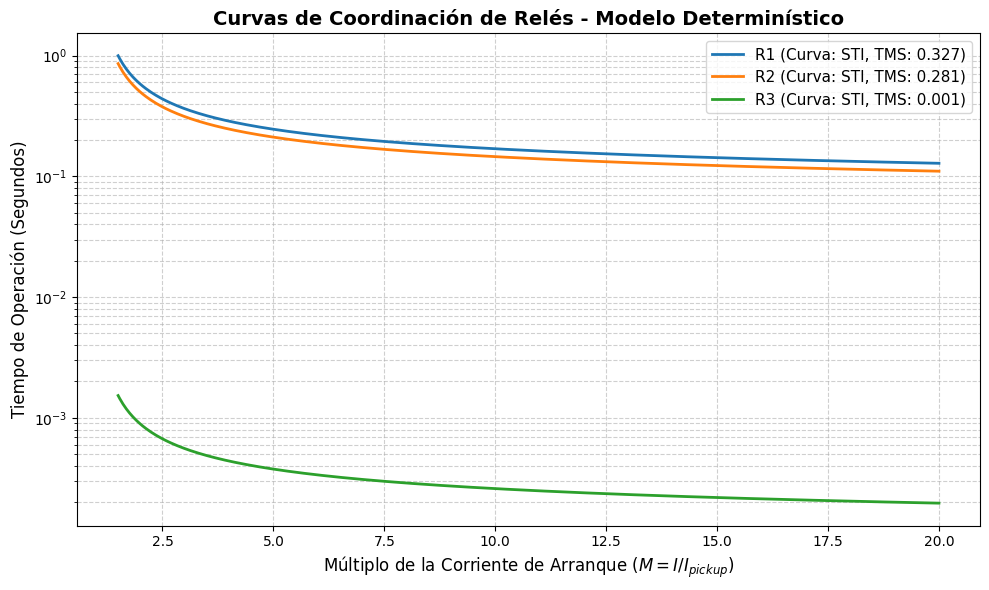

In [ ]:

# =====================================================================
# 1. CARGA Y PROCESAMIENTO DE DATOS
# =====================================================================
print("--- Iniciando procesamiento de datos ---")
csv_path = 'beta_df.csv'
try:
    beta_df = pd.read_csv(csv_path)
except FileNotFoundError:
    print(f"Archivo {csv_path} no encontrado. Creando datos de prueba...")
    # Datos simulados en caso de que el archivo no exista
    data = {'Falla': ['F1']*12, 'Rele': ['R1','R1','R2','R2','R3','R3']*2,
            'Curva': ['STI','SI','STI','SI','STI','SI']*2,
            'Distancia': [0.1]*6 + [0.2]*6,
            'Beta': [1.1, 6.2, 0.66, 3.8, 0.66, 3.8, 1.12, 6.3, 0.67, 3.86, 0.67, 3.86]}
    beta_df = pd.DataFrame(data)

# Filtrar valores negativos de Beta
filtered_df = beta_df[beta_df['Beta'] >= 0]

# Definición de Conjuntos del Sistema
R = ['R1', 'R2', 'R3']
C = ['STI', 'SI'] # Agregar 'VI', 'EI' si existen en tu dataset real
P = [('R2', 'R1'), ('R3', 'R1'), ('R3', 'R2')] # (Relé Principal i, Relé Respaldo j)
F = 'F1' # Falla objetivo para la coordinación

# Diccionarios para almacenar parámetros extraídos
k1_dict = {}
k2_dict = {}
beta0_dict = {}  # Valor nominal (promedio) de beta_jq
beta_obj_dict = {} # Betas promedio para la función objetivo

# EXTRACCIÓN DE k1, k2 Y PARÁMETROS NOMINALES
for i, j in P:
    for c in C:     # Curva del Principal
        for q in C: # Curva del Respaldo

            # Filtrar DataFrames
            df_prin = filtered_df[(filtered_df['Rele'] == i) & (filtered_df['Curva'] == c) & (filtered_df['Falla'] == F)]
            df_back = filtered_df[(filtered_df['Rele'] == j) & (filtered_df['Curva'] == q) & (filtered_df['Falla'] == F)]

            # Alinear datos por distancia
            df_merged = pd.merge(df_prin, df_back, on='Distancia', suffixes=('_prin', '_back')).sort_values(by='Distancia')

            y = df_merged['Beta_prin'].to_numpy() # Principal
            x = df_merged['Beta_back'].to_numpy() # Respaldo

            # Interpolar linealmente (y = k2 * x + k1)
            if len(x) >= 2:
                k2, k1 = np.polyfit(x, y, 1)
            else:
                k2, k1 = 1.0, 0.0 # Valores por defecto si no hay suficientes datos

            k1_dict[(i, j, q, c)] = k1
            k2_dict[(i, j, q, c)] = k2

            # Extraer límite nominal para el respaldo (q) si no existe aún
            if (j, q) not in beta0_dict:
                if len(x) > 0:
                    b0 = np.mean(x)
                else:
                    b0 = 1.0

                beta0_dict[(j, q)] = b0

# Extraer betas promedio para la función objetivo (sum beta_ic * y_ic)
for i in R:
    for c in C:
        df_obj = filtered_df[(filtered_df['Rele'] == i) & (filtered_df['Curva'] == c)]
        beta_obj_dict[(i, c)] = df_obj['Beta'].mean() if not df_obj.empty else 1.0

# =====================================================================
# 2. CONSTRUCCIÓN DEL MODELO DETERMINÍSTICO EN PYOMO
# =====================================================================
print("--- Construyendo Modelo Determinístico en Pyomo ---")

model = pyo.ConcreteModel(name="Deterministic_Coordination_V2")

# --- Sets ---
model.R = pyo.Set(initialize=R)
model.C = pyo.Set(initialize=C)
model.P = pyo.Set(dimen=2, initialize=P) # Pares (Principal, Respaldo)

# --- Parámetros ---
model.CTI = pyo.Param(initialize=0.2)
model.M   = pyo.Param(initialize=1000.0) # Constante Big-M
model.y_lb = pyo.Param(initialize=0.0005)
model.y_ub = pyo.Param(initialize=1.2)

# Parámetro C_c (Constantes de curva estándar, 0 para STI y SI)
C_index = {"STI": 0.0, "SI": 0.0, "VI": 0.0, "EI": 0.0}
def c_param_init(model, c):
    return C_index.get(c, 0.0)
model.C_param = pyo.Param(model.C, initialize=c_param_init)

# Diccionarios pasados como parámetros en Pyomo
model.k1    = pyo.Param(model.P, model.C, model.C, initialize=k1_dict)
model.k2    = pyo.Param(model.P, model.C, model.C, initialize=k2_dict)
model.beta0 = pyo.Param(model.R, model.C, initialize=beta0_dict, default=1.0)
model.beta_obj = pyo.Param(model.R, model.C, initialize=beta_obj_dict)

# --- Variables ---
# y_ic: TMS (Time Multiplier Setting) continuo
model.y = pyo.Var(model.R, model.C, domain=pyo.NonNegativeReals)
# x_ic: Selección de curva binaria
model.x = pyo.Var(model.R, model.C, domain=pyo.Binary)

# --- Función Objetivo ---
# minimizar sum( beta_fic * y_ic + x_ic * C_c )
def obj_rule(model):
    return sum(model.beta_obj[i, c] * model.y[i, c] + model.x[i, c] * model.C_param[c]
               for i in model.R for c in model.C)
model.objective = pyo.Objective(rule=obj_rule, sense=pyo.minimize)

# --- Restricciones ---

# 1. Selección de curva única por relé
def single_curve_rule(model, i):
    return sum(model.x[i, c] for c in model.C) == 1
model.single_curve = pyo.Constraint(model.R, rule=single_curve_rule)

# 2. Límites de TMS (Activados por la variable binaria x_ic)
def tms_lower_rule(model, i, c):
    return model.y[i, c] >= model.y_lb * model.x[i, c]
model.tms_lower = pyo.Constraint(model.R, model.C, rule=tms_lower_rule)

def tms_upper_rule(model, i, c):
    return model.y[i, c] <= model.y_ub * model.x[i, c]
model.tms_upper = pyo.Constraint(model.R, model.C, rule=tms_upper_rule)

# 3. Restricciones de Coordinación (Nominal)
# i: Principal, j: Respaldo, c: Curva Principal, q: Curva Respaldo
def det_base_rule(model, i, j, q, c):
    nominal_part = (model.k1[i,j,q,c] * model.y[i,c] +
                    model.k2[i,j,q,c] * model.beta0[j,q] * model.y[i,c] -
                    model.beta0[j,q] * model.y[j,q] +
                    model.C_param[c] - model.C_param[q] + model.CTI)

    return nominal_part <= model.M * (2 - model.x[j,q] - model.x[i,c])
model.det_base = pyo.Constraint(model.P, model.C, model.C, rule=det_base_rule)

# =====================================================================
# 3. RESOLUCIÓN DEL MODELO Y GRÁFICAS
# =====================================================================
print("--- Iniciando Optimización ---")
try:
    # Utilizando appsi_highs, compatible y rápido en Colab
    solver = pyo.SolverFactory('appsi_highs')

    results = solver.solve(model, tee=True)

    print("\nEstado de la Optimización:", results.solver.status)
    print("Condición de término:", results.solver.termination_condition)

    print("\n--- Resultados Óptimos ---")

    # Guardar resultados para graficar
    resultados_optimos = {}

    for i in model.R:
        for c in model.C:
            if pyo.value(model.x[i, c]) > 0.5: # Si se seleccionó la curva
                tms_val = pyo.value(model.y[i, c])
                print(f"Relé {i} -> Curva Seleccionada: {c} | TMS (y) = {tms_val:.4f}")
                resultados_optimos[i] = {'curva': c, 'tms': tms_val}

    # --- Generación de Gráfica de Coordinación (Tiempo vs Corriente) ---
    print("\n--- Generando Gráfica de Coordinación ---")

    # Parámetros estándar de las curvas IEC para la ecuación: t = TMS * (A / (M^B - 1)) + C
    parametros_curvas = {
        "STI": {"A": 0.05, "B": 0.04, "C": 0.0},
        "SI": {"A": 0.14, "B": 0.02, "C": 0.0},
        "VI": {"A": 13.5, "B": 1.0, "C": 0.0},
        "EI": {"A": 80.0, "B": 2.0, "C": 0.0}
    }

    # Rango de múltiplo de corriente de arranque (M = I / I_pickup), típicamente de 1.5 a 20
    M = np.linspace(1.5, 20, 500)

    plt.figure(figsize=(10, 6))
    colores = {'R1': '#1f77b4', 'R2': '#ff7f0e', 'R3': '#2ca02c'}

    for rele, datos in resultados_optimos.items():
        c_nombre = datos['curva']
        tms = datos['tms']

        A = parametros_curvas[c_nombre]['A']
        B = parametros_curvas[c_nombre]['B']
        C_cte = parametros_curvas[c_nombre]['C']

        # Ecuación estándar de tiempo de operación
        tiempo_operacion = tms * (A / (M**B - 1.0)) + C_cte

        plt.plot(M, tiempo_operacion, label=f'{rele} (Curva: {c_nombre}, TMS: {tms:.3f})',
                 color=colores.get(rele, 'black'), linewidth=2)

    plt.xlabel('Múltiplo de la Corriente de Arranque ($M = I / I_{pickup}$)', fontsize=12)
    plt.ylabel('Tiempo de Operación (Segundos)', fontsize=12)
    plt.title('Curvas de Coordinación de Relés - Modelo Determinístico', fontsize=14, fontweight='bold')

    plt.yscale('log') # Usualmente estas gráficas se ven mejor en escala logarítmica (Tiempo)
    plt.grid(True, which="both", ls="--", alpha=0.6)
    plt.legend(fontsize=11)

    # Muestra la gráfica
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"\nNo se pudo resolver el modelo o generar la gráfica. Detalles del error: {e}")